In [46]:
import numpy as np
from affine import Affine
from scipy.ndimage import gaussian_filter
from rasterio.features import rasterize, geometry_mask
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches
import os
import fiona
import rasterio
from rasterio.enums import MergeAlg
from sklearn.preprocessing import MinMaxScaler
from shapely.geometry import Point
import libpysal
import esda
import rasterstats
import warnings
warnings.filterwarnings("ignore")
import sys
import importlib

sys.path.insert(0, os.path.abspath("../.."))


In [47]:
import utils.config
import utils.functions
importlib.reload(utils.config)
importlib.reload(utils.functions)

from utils.config import *
from utils.functions import *

config.py - All is good
99
functions.py - All is good


In [48]:
#Read the files
index_walkability = gpd.read_parquet(f'{output_step3_path}/step3_index.parquet')
index_walkability = index_walkability.to_crs(operation_crs)

carreau_200 = gpd.read_file(f'{output_step3_path}/step3_aggregated_index_carreau200.gpkg')
carreau_200 = carreau_200.to_crs(operation_crs)

zones_girec = gpd.read_file(f'{output_step3_path}/step3_aggregated_index_girec.gpkg')
zones_girec = zones_girec.to_crs(operation_crs)


user_stat  = pd.read_csv(f'{input_file_path_PL}/241120_user_statistics.csv')

agglo_GG  = gpd.read_file(f'{input_file_path}/network_agreg/AGGLO_PERIMETRE_AVEC_LAC-SHP/AGGLO_PERIMETRE_AVEC_LAC.shp')
agglo_GG = agglo_GG.to_crs(operation_crs)

respondants_wave1 = pd.read_csv(f'{output_file_path_PL_wave1}respondants_all_wave1.csv')

# DATA LOADING

In [49]:
# ─── Comptage brut du fichier original (sans filtres) ─────────────────────────
layers = fiona.listlayers(f'{input_file_path_PL}241120_legs.gpkg')

total_legs = 0
all_user_ids = set()

for layer in layers:
    gdf_raw = gpd.read_file(
        f'{input_file_path_PL}241120_legs.gpkg',
        layer=layer,
        columns=["user_id_fors"]  # charge uniquement la colonne nécessaire
    )
    total_legs += len(gdf_raw)
    all_user_ids.update(gdf_raw["user_id_fors"].dropna().unique())

print(f"Fichier original : {total_legs} legs / {len(all_user_ids)} utilisateurs")

Fichier original : 669277 legs / 2806 utilisateurs


## LEGS_GG_ALL (tous les déplacements dans Genève, tous modes confondus)

In [50]:
# ─── Préparation du périmètre géographique Grand Genève (agglo_GG) ────────────
from shapely.geometry import LineString, MultiLineString

# On fusionne toutes les géométries de agglo_GG en une seule pour le test
# d'appartenance (au cas où le shapefile contient plusieurs polygones/îles).
try:
    agglo_GG_geom = agglo_GG.union_all()          # geopandas >= 0.14
except AttributeError:
    agglo_GG_geom = agglo_GG.unary_union           # fallback anciennes versions


def get_start_end_points(geom):
    """Retourne les points de début et de fin d'une géométrie de leg (LineString)."""
    if geom is None or geom.is_empty:
        return None, None
    if isinstance(geom, LineString):
        coords = list(geom.coords)
        return Point(coords[0]), Point(coords[-1])
    if isinstance(geom, MultiLineString):
        parts = list(geom.geoms)
        return Point(list(parts[0].coords)[0]), Point(list(parts[-1].coords)[-1])
    # cas de repli (ex: géométrie déjà en Point)
    return geom, geom


def compute_intra_GG(gdf, perimeter_geom, perimeter_crs):
    """
    intra_GG = 1 si le point de départ ET le point d'arrivée du leg
    sont contenus dans le périmètre Grand Genève (agglo_GG).
    """
    gdf_proj = gdf.to_crs(perimeter_crs)

    starts, ends = zip(*gdf_proj.geometry.map(get_start_end_points))
    starts = gpd.GeoSeries(starts, crs=perimeter_crs)
    ends   = gpd.GeoSeries(ends,   crs=perimeter_crs)

    start_in = starts.within(perimeter_geom)
    end_in   = ends.within(perimeter_geom)

    return (start_in & end_in).fillna(False).astype(int).values


# ─── Chargement tous modes, filtres qualité + sélection géographique GG ───────
layers     = fiona.listlayers(f'{input_file_path_PL}241120_legs.gpkg')
all_layers = []

for layer in layers:
    where_clause = """
        extreme99_length_mode = 0 AND
        extreme98_length_mode = 0 AND
        usr_w_constant_bad_signal = 0

    """

    gdf = gpd.read_file(
        f'{input_file_path_PL}241120_legs.gpkg',
        layer=layer,
        where=where_clause
    )

    if len(gdf) > 0:
        gdf["intra_GG"] = compute_intra_GG(gdf, agglo_GG_geom, agglo_GG.crs)
        gdf = gdf[gdf["intra_GG"] == 1].copy()

    print(f"── {layer:<25} selected: {len(gdf):>6}")
    if len(gdf) > 0:
        gdf["source_layer"] = layer
        all_layers.append(gdf)

legs_GG_all = gpd.GeoDataFrame(
    pd.concat(all_layers, ignore_index=True),
    crs="EPSG:4326"
)
del all_layers

print(f"\nlegs_all_GG : {len(legs_GG_all)} legs / {legs_GG_all['user_id_fors'].nunique()} utilisateurs")


── layer_VD                  selected:  41602
── layer_not_declared        selected:   6123
── layer_GE                  selected: 102132
── layer_VS                  selected:    186
── layer_FR                  selected:      5
── layer_ZH                  selected:     17
── layer_BE                  selected:     20
── layer_Fra                 selected:  90072

legs_all_GG : 240157 legs / 1997 utilisateurs


In [51]:
len(layers)

8

In [52]:
print(legs_GG_all.dtypes.to_string())

leg_id                                    object
user_id_day                               object
user_id_motiontag                         object
user_id_fors                              object
type                                      object
legs_date                         datetime64[ms]
started_at                        datetime64[ms]
started_at_timezone                       object
finished_at                       datetime64[ms]
finished_at_timezone                      object
length_leg                               float64
duration                                 float64
leading_stay_purpose                      object
detected_mode                             object
mode                                      object
started_on                                object
misdetected_completely                    object
merged                                    object
confirmed_at                              object
created_at                                object
updated_at          

In [53]:
from IPython.display import display, HTML
display(HTML(legs_GG_all.drop(columns='geometry').head(10).to_html()))

,leg_id,user_id_day,user_id_motiontag,user_id_fors,type,legs_date,started_at,started_at_timezone,finished_at,finished_at_timezone,length_leg,duration,leading_stay_purpose,detected_mode,mode,started_on,misdetected_completely,merged,confirmed_at,created_at,updated_at,started_at_in_timezone,finished_at_in_timezone,confirmed_at_in_timezone,created_at_in_timezone,updated_at_in_timezone,point_per_linestring,max_signlalloss_meters,rel_max_signalloss,low_quality_legs_1,low_quality_legs_2,leading_stay_id,usr_w_constant_bad_signal,leading_activity_in_KT,leading_activity_in_panel,main_journey_act_KT,KT_home_survey,intra_GE,intra_VD,intra_panel,extreme95_length_detected_mode,extreme98_length_detected_mode,extreme99_length_detected_mode,extreme95_length_mode,extreme98_length_mode,extreme99_length_mode,intra_GG,source_layer
0,0cd0de7f-cb27-4fd8-a9b0-c29caab45e39,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 06:59:45,Europe/Zurich,2023-04-25 07:12:07,Europe/Zurich,2095.0,742.0,shopping,Mode::Bicycle,Mode::Bicycle,2023-04-25,f,f,2023-04-26 16:33:41.811,2023-04-25 07:18:41.211,2023-04-26 16:33:41.811,2023-04-25T08:59:45+02:00,2023-04-25T09:12:07+02:00,2023-04-26T16:33:41Z,2023-04-25T07:18:41Z,2023-04-26T16:33:41Z,97,96.858780,0.046214,0,0,b346a3cb-2b3c-445b-a471-1dcda1e93a54,0,VD,1.0,VD,VD,0.0,1.0,1.0,False,False,False,False,False,False,1,layer_VD
1,3995dcbe-47a8-4ac0-9e23-0761f6d56c3b,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 15:37:52,Europe/Zurich,2023-04-25 15:48:03,Europe/Zurich,177.0,611.0,wait,Mode::Walk,Mode::Walk,2023-04-25,f,f,2023-04-26 16:33:41.941,2023-04-25 16:13:16.888,2023-04-26 16:33:41.941,2023-04-25T17:37:52+02:00,2023-04-25T17:48:03+02:00,2023-04-26T16:33:41Z,2023-04-25T16:13:16Z,2023-04-26T16:33:41Z,29,88.624728,0.498877,0,0,c198bb5c-0345-4cab-83f5-486a82fc5257,0,VD,1.0,VD,VD,0.0,1.0,1.0,False,False,False,False,False,False,1,layer_VD
2,69916c78-ed3d-4f34-81e2-1e755de0bd3c,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 15:54:00,Europe/Zurich,2023-04-25 15:56:49,Europe/Zurich,712.0,169.0,wait,Mode::Bicycle,Mode::Bicycle,2023-04-25,f,f,2023-04-26 16:33:41.931,2023-04-25 16:13:17.034,2023-04-26 16:33:41.931,2023-04-25T17:54:00+02:00,2023-04-25T17:56:49+02:00,2023-04-26T16:33:41Z,2023-04-25T16:13:17Z,2023-04-26T16:33:41Z,34,53.327488,0.074802,0,0,d5fcae5d-2e3f-4a8a-94c7-063c166cd152,0,VD,1.0,VD,VD,0.0,1.0,1.0,False,False,False,False,False,False,1,layer_VD
3,d831bc52-3650-4c51-9b49-59ab1b2f386d,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 15:57:59,Europe/Zurich,2023-04-25 15:59:27,Europe/Zurich,91.0,88.0,shopping,Mode::Walk,Mode::Walk,2023-04-25,f,f,2023-04-26 16:33:41.918,2023-04-25 16:13:17.172,2023-04-26 16:33:41.918,2023-04-25T17:57:59+02:00,2023-04-25T17:59:27+02:00,2023-04-26T16:33:41Z,2023-04-25T16:13:17Z,2023-04-26T16:33:41Z,16,32.772907,0.358024,0,0,e6c1e7e3-6dfe-436f-a60f-af4b9a2249b3,0,VD,1.0,VD,VD,0.0,1.0,1.0,False,False,False,False,False,False,1,layer_VD
4,2fa45c1f-2353-4fbe-abca-f04eb1ec51b8,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 16:02:05,Europe/Zurich,2023-04-25 16:04:15,Europe/Zurich,651.0,130.0,home,Mode::Bicycle,Mode::Bicycle,2023-04-25,f,f,2023-04-26 16:33:41.837,2023-04-25 16:13:17.311,2023-04-26 16:33:41.837,2023-04-25T18:02:05+02:00,2023-04-25T18:04:15+02:00,2023-04-26T16:33:41Z,2023-04-25T16:13:17Z,2023-04-26T16:33:41Z,24,85.531166,0.131192,0,0,2c8113f8-7624-42aa-a215-66a8168afcd1,0,VD,1.0,VD,VD,0.0,1.0,1.0,False,False,False,False,False,False,1,layer_VD
5,064e2e23-5186-4d49-b560-abd18cfc19c3,CH10003_20230426,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-26,2023-04-26 05:13:42,Europe/Zurich,2023-04-26 05:20:35,Europe/Zurich,128.0,413.0,home,Mode::Walk,Mode::Walk,2023-04-26,t,f,2023-04-26 16:34:21.624,2023-04-26 05:56:13.451,2023-04-26 16:36:58.483,2023-04-26T07:13:42+0

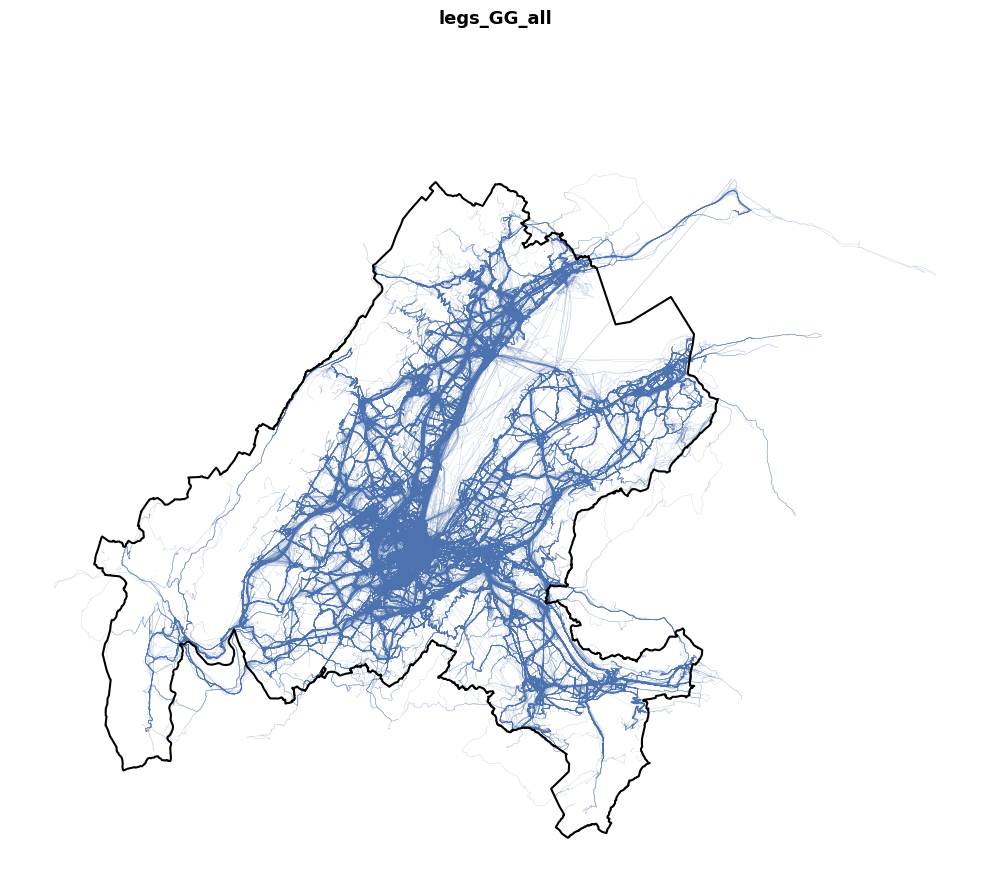

In [54]:
fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle("legs_GG_all", fontsize=13, fontweight="bold")

legs_GG_all.to_crs(2056).plot(ax=ax, color="#4C72B0", linewidth=0.3, alpha=0.3)
agglo_GG.boundary.plot(ax=ax, color='black', linewidth=1.5)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### AJOUT COL LEGSGGALL

In [56]:
# ─── Merges socio-démo ────────────────────────────────────────────────────────

# Merge user_stat
cols_to_add = ["user_id_fors"] + [
    col for col in user_stat.columns
    if col not in legs_GG_all.columns
]
legs_GG_all = legs_GG_all.merge(user_stat[cols_to_add], on="user_id_fors", how="left")

# Merge respondants_wave1 (abonnements + revenus)
abo_cols_1  = [f'Q10_{i}_R' for i in range(1, 10)]
abo_cols_2  = [f'Q11_{i}_R' for i in range(1, 10)]
revenu_cols = ["Q120", "Q121"]
physical_cond_col = ["Q108_new"]
compo_menage = [f'Q119_{i}' for i in range(1, 10)]
all_cols    = abo_cols_1 + abo_cols_2 + revenu_cols + physical_cond_col + compo_menage
cols_wave1  = [c for c in all_cols if c in respondants_wave1.columns and c not in legs_GG_all.columns]

if cols_wave1:
    legs_GG_all = legs_GG_all.merge(
        respondants_wave1[["id"] + cols_wave1].rename(columns={"id": "user_id_fors"}),
        on="user_id_fors",
        how="left"
    )

# Merge trip/journey
leg_trip_journey = pd.read_csv(f'{input_file_path_PL}241120_map_track_trip_journey.csv')
legs_GG_all = legs_GG_all.merge(leg_trip_journey, on="leg_id", how="left")

In [58]:
# ─── Regroupement age 60+ ─────────────────────────────────────────────────────
legs_GG_all["age_fr_grouped"] = legs_GG_all["age_fr"].replace({
    "60-74 ans"      : "60 ans +",
    "75 ans et plus" : "60 ans +",
})

# ─── Vérification ─────────────────────────────────────────────────────────────
print(legs_GG_all[["age_fr", "age_fr_grouped"]].drop_duplicates().sort_values("age_fr_grouped").to_string(index=False))

        age_fr age_fr_grouped
     18-29 ans      18-29 ans
     30-44 ans      30-44 ans
     45-59 ans      45-59 ans
     60-74 ans       60 ans +
75 ans et plus       60 ans +
           NaN            NaN


In [59]:
# ─── Vérifier les modes disponibles ──────────────────────────────────────────
print("── Modes disponibles ────────────────────────────────")
print(legs_GG_all["mode"].value_counts())

── Modes disponibles ────────────────────────────────
mode
Mode::Walk             128613
Mode::Car               66931
Mode::Bus               12702
Mode::Bicycle           12300
Mode::Tram               5741
Mode::Motorbike          3060
Mode::Train              2857
Mode::Ecar               2776
Mode::Ebicycle           2773
Mode::RegionalTrain      1040
Mode::Other               420
Mode::LightRail           292
Mode::Carsharing          282
Mode::Boat                159
Mode::KickScooter         138
Mode::TaxiUber             63
Mode::Airplane              8
Mode::Bikesharing           1
Mode::Subway                1
Name: count, dtype: int64


In [60]:
# ─── Variables calculées ──────────────────────────────────────────────────────
legs_GG_all = legs_GG_all.assign(
    length_weighted = lambda x: x['length_leg'] * x['wgt_cant_trim_gps'] * x['intra_GG'],
)

# ─── Mapping mode → groupe ────────────────────────────────────────────────────
mode_to_group = {
    mode: group
    for group, modes in mode_groups.items()
    for mode in modes
}
legs_GG_all["mode_group"] = legs_GG_all["mode"].map(mode_to_group).fillna("other")

# ─── Stats globales par user ──────────────────────────────────────────────────
_stats = legs_GG_all.groupby('user_id_fors').agg(
    n_legs_total = ('leg_id',          'count'),
    dist_total   = ('length_weighted', 'sum'),
    n_days_GE    = ('legs_date',       'nunique'),
).reset_index()

# ─── Distance et legs par mode par user ───────────────────────────────────────
_dist_by_mode = (
    legs_GG_all
    .groupby(["user_id_fors", "mode_group"])["length_weighted"]
    .sum()
    .unstack(fill_value=0)
    .add_prefix("dist_")
    .reset_index()
)

_legs_by_mode = (
    legs_GG_all
    .groupby(["user_id_fors", "mode_group"])["leg_id"]
    .count()
    .unstack(fill_value=0)
    .add_prefix("n_legs_")
    .reset_index()
)

# ─── Stats spécifiques à la marche ────────────────────────────────────────────
_walk_stats = (
    legs_GG_all[legs_GG_all["mode_group"] == "walk"]
    .groupby("user_id_fors")
    .agg(
        n_walk_days = ('legs_date', 'nunique'),  # ← jours avec au moins 1 leg marche
    )
    .reset_index()
)

# ─── Merger tout ──────────────────────────────────────────────────────────────
_stats = _stats.merge(_dist_by_mode,  on="user_id_fors", how="left")
_stats = _stats.merge(_legs_by_mode,  on="user_id_fors", how="left")
_stats = _stats.merge(_walk_stats,    on="user_id_fors", how="left")

# ─── Fillna ───────────────────────────────────────────────────────────────────
for group in mode_groups.keys():
    for prefix in ["dist_", "n_legs_"]:
        col = f"{prefix}{group}"
        if col in _stats.columns:
            _stats[col] = _stats[col].fillna(0)
_stats["n_walk_days"] = _stats["n_walk_days"].fillna(0)

# ─── Parts modales et distances journalières par mode ─────────────────────────
for group in mode_groups.keys():
    dist_col  = f"dist_{group}"
    legs_col  = f"n_legs_{group}"

    if dist_col in _stats.columns:
        _stats[f"dist_{group}_per_day"]  = _stats[dist_col] / _stats["n_days_GE"]
        _stats[f"share_dist_{group}"]    = _stats[dist_col] / _stats["dist_total"]
        _stats[f"share_legs_{group}"]    = _stats[legs_col] / _stats["n_legs_total"]

# ─── Métriques spécifiques marche ─────────────────────────────────────────────
_stats["walk_share_dist"]         = _stats["dist_walk"]   / _stats["dist_total"]
_stats["walk_share_legs"]         = _stats["n_legs_walk"] / _stats["n_legs_total"]
_stats["dist_walk_per_day"]       = _stats["dist_walk"]   / _stats["n_days_GE"]
_stats["dist_walk_per_walk_day"]  = np.where(
    _stats["n_walk_days"] > 0,
    _stats["dist_walk"] / _stats["n_walk_days"],
    np.nan
)


_stats["mean_walk_legs_per_day"] = _stats["n_legs_walk"] / _stats["n_days_GE"]



# ─── Flag revenu ──────────────────────────────────────────────────────────────
legs_GG_all['a_repondu_revenu'] = (
    (legs_GG_all['Q120'].notna() & (legs_GG_all['Q120'] != 10)) |
    (legs_GG_all['Q121'].notna() & (legs_GG_all['Q121'] != 12))
)

# ─── Merger sur legs_GG_all ───────────────────────────────────────────────────
legs_GG_all = legs_GG_all.merge(_stats, on='user_id_fors', how='left')
del _stats, _dist_by_mode, _legs_by_mode, _walk_stats

# ─── Vérification ─────────────────────────────────────────────────────────────
print(f"legs_GG_all enrichi : {len(legs_GG_all)} legs / {legs_GG_all['user_id_fors'].nunique()} users")
print(f"Colonnes            : {len(legs_GG_all.columns)}")
print(f"\n── Nouvelles colonnes ───────────────────────────────")
for group in mode_groups.keys():
    print(f"  dist_{group:<25} | dist_{group}_per_day | share_dist_{group} | share_legs_{group}")
print(f"  dist_walk_per_walk_day | mean_walk_legs_per_day | n_walk_days")

legs_GG_all enrichi : 240157 legs / 1997 users
Colonnes            : 177

── Nouvelles colonnes ───────────────────────────────
  dist_walk                      | dist_walk_per_day | share_dist_walk | share_legs_walk
  dist_car                       | dist_car_per_day | share_dist_car | share_legs_car
  dist_public_transit            | dist_public_transit_per_day | share_dist_public_transit | share_legs_public_transit
  dist_train                     | dist_train_per_day | share_dist_train | share_legs_train
  dist_bicycle                   | dist_bicycle_per_day | share_dist_bicycle | share_legs_bicycle
  dist_vehicle_equivalent_device | dist_vehicle_equivalent_device_per_day | share_dist_vehicle_equivalent_device | share_legs_vehicle_equivalent_device
  dist_2WV                       | dist_2WV_per_day | share_dist_2WV | share_legs_2WV
  dist_boat                      | dist_boat_per_day | share_dist_boat | share_legs_boat
  dist_airplane                  | dist_airplane_per_day | sh

In [61]:
# ─── Variables temporelles ────────────────────────────────────────────────────
legs_GG_all["started_at_local"]  = pd.to_datetime(legs_GG_all["started_at_in_timezone"], utc=True).dt.tz_convert("Europe/Zurich")
legs_GG_all["finished_at_local"] = pd.to_datetime(legs_GG_all["finished_at_in_timezone"], utc=True).dt.tz_convert("Europe/Zurich")

legs_GG_all["hour"]            = legs_GG_all["started_at_local"].dt.hour
legs_GG_all["hour_end"]        = legs_GG_all["finished_at_local"].dt.hour
legs_GG_all["time_slot"]       = legs_GG_all["started_at_local"].dt.floor("15min").dt.strftime("%H:%M")
legs_GG_all["legs_date"]       = legs_GG_all["started_at_local"].dt.date
legs_GG_all["day_of_week"]     = legs_GG_all["started_at_local"].dt.day_name()
legs_GG_all["day_of_week_num"] = legs_GG_all["started_at_local"].dt.dayofweek
legs_GG_all["duration_min"]    = legs_GG_all["duration"] / 60

legs_GG_all['duration_min_weighted'] = (
    legs_GG_all['duration_min'] * legs_GG_all['wgt_cant_trim_gps'] * legs_GG_all['intra_GG']
)

# ─── Durée totale de marche par utilisateur ───────────────────────────────────
_dur_walk = (
    legs_GG_all[legs_GG_all['mode'] == 'Mode::Walk']
    .groupby('user_id_fors')['duration_min_weighted']
    .sum()
    .rename('total_duration_walk_min')
    .reset_index()
)

legs_GG_all = legs_GG_all.merge(_dur_walk, on='user_id_fors', how='left')
del _dur_walk

legs_GG_all['total_duration_walk_min']    = legs_GG_all['total_duration_walk_min'].fillna(0)
legs_GG_all['mean_walk_duration_per_day'] = (
    legs_GG_all['total_duration_walk_min'] / legs_GG_all['n_days_GE']
)

print(f"Vérification durée moyenne : {legs_GG_all.drop_duplicates('user_id_fors')['mean_walk_duration_per_day'].median():.1f} min/jour")

Vérification durée moyenne : 10.4 min/jour


In [62]:
# ─── Flag timestamp_error (vitesse > 30 km/h sur legs de marche) ─────────────
WALK_SPEED_MAX_KMH = 30

legs_GG_all["speed_kmh"] = (
    legs_GG_all["length_leg"] / (legs_GG_all["duration_min"] / 60) / 1000
)

legs_GG_all["timestamp_error"] = (
    (legs_GG_all["mode"] == "Mode::Walk") &
    (legs_GG_all["speed_kmh"] > WALK_SPEED_MAX_KMH)
).astype(int)

print(f"Legs flaggés timestamp_error : {legs_GG_all['timestamp_error'].sum()} "
      f"({legs_GG_all['timestamp_error'].mean()*100:.2f}% des legs)")
print(f"Utilisateurs concernés : {legs_GG_all[legs_GG_all['timestamp_error']==1]['user_id_fors'].nunique()}")

Legs flaggés timestamp_error : 859 (0.36% des legs)
Utilisateurs concernés : 536


In [63]:
# ─── Insérer les labels juste après les colonnes Q120 et Q121 ─────────────────
idx_Q120 = legs_GG_all.columns.get_loc('Q120') + 1
legs_GG_all.insert(idx_Q120, 'Q120_label', legs_GG_all['Q120'].map(income_labels_Q120))

idx_Q121 = legs_GG_all.columns.get_loc('Q121') + 1
legs_GG_all.insert(idx_Q121, 'Q121_label', legs_GG_all['Q121'].map(income_labels_Q121))

In [64]:
from IPython.display import display, HTML
display(HTML(legs_GG_all.drop(columns='geometry').head(10).to_html()))

,leg_id,user_id_day,user_id_motiontag,user_id_fors,type,legs_date,started_at,started_at_timezone,finished_at,finished_at_timezone,length_leg,duration,leading_stay_purpose,detected_mode,mode,started_on,misdetected_completely,merged,confirmed_at,created_at,updated_at,started_at_in_timezone,finished_at_in_timezone,confirmed_at_in_timezone,created_at_in_timezone,updated_at_in_timezone,point_per_linestring,max_signlalloss_meters,rel_max_signalloss,low_quality_legs_1,low_quality_legs_2,leading_stay_id,usr_w_constant_bad_signal,leading_activity_in_KT,leading_activity_in_panel,main_journey_act_KT,KT_home_survey,intra_GE,intra_VD,intra_panel,extreme95_length_detected_mode,extreme98_length_detected_mode,extreme99_length_detected_mode,extreme95_length_mode,extreme98_length_mode,extreme99_length_mode,intra_GG,source_layer,Unnamed: 0_x,first_activity_date,last_activity_date,days_in_range,gps_days_count,days_without_gps,track_days_count,staypoint_days_count,count_days_w_journey_in_GE,count_days_w_journey_in_VD,gps_activity_rate,confirmed_tracks_count,tracks_count,confirmation_tracks_score,confirmed_stay_count,stay_count,confirmation_stay_score,ID_municipality_survey,home_geometry_from_survey,ID_Agglo_survey,N_Agglo_survey,typo_panel_home_survey,KT_home_gps,home_geometry_from_gps,gdr,prof,age_fr,wgt_cant_gps,wgt_agg_gps,wgt_cant_trim_gps,wgt_agg_trim_gps,main_motor,car_in_HH_count,Q10_1_R,Q10_2_R,Q10_3_R,Q10_4_R,Q10_5_R,Q10_6_R,Q10_7_R,Q10_8_R,Q10_9_R,Q11_1_R,Q11_2_R,Q11_3_R,Q11_4_R,Q11_5_R,Q11_6_R,Q11_7_R,Q11_8_R,Q11_9_R,Q120,Q120_label,Q121,Q121_label,Q108_new,Q119_1,Q119_2,Q119_3,Q119_4,Q119_5,Q119_6,Q119_7,Q119_8,Q119_9,Unnamed: 0_y,trip_id,journey_id,age_fr_grouped,length_weighted,mode_group,a_repondu_revenu,n_legs_total,dist_total,n_days_GE,dist_2WV,dist_airplane,dist_bicycle,dist_boat,dist_car,dist_other,dist_public_transit,dist_train,dist_vehicle_equivalent_device,dist_walk,n_legs_2WV,n_legs_airplane,n_legs_bicycle,n_legs_boat,n_legs_car,n_legs_other,n_legs_public_transit,n_legs_train,n_legs_vehicle_equivalent_device,n_legs_walk,n_walk_days,dist_walk_per_day,share_dist_walk,share_legs_walk,dist_car_per_day,share_dist_car,share_legs_car,dist_public_transit_per_day,share_dist_public_transit,share_legs_public_transit,dist_train_per_day,share_dist_train,share_legs_train,dist_bicycle_per_day,share_dist_bicycle,share_legs_bicycle,dist_vehicle_equivalent_device_per_day,share_dist_vehicle_equivalent_device,share_legs_vehicle_equivalent_device,dist_2WV_per_day,share_dist_2WV,share_legs_2WV,dist_boat_per_day,share_dist_boat,share_legs_boat,dist_airplane_per_day,share_dist_airplane,share_legs_airplane,dist_other_per_day,share_dist_other,share_legs_other,walk_share_dist,walk_share_legs,dist_walk_per_walk_day,mean_walk_legs_per_day,started_at_local,finished_at_local,hour,hour_end,time_slot,day_of_week,day_of_week_num,duration_min,duration_min_weighted,total_duration_walk_min,mean_walk_duration_per_day,speed_kmh,timestamp_error
0,0cd0de7f-cb27-4fd8-a9b0-c29caab45e39,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 06:59:45,Europe/Zurich,2023-04-25 07:12:07,Europe/Zurich,2095.0,742.0,shopping,Mode::Bicycle,Mode::Bicycle,2023-04-25,f,f,2023-04-26 16:33:41.811,2023-04-25 07:18:41.211,2023-04-26 16:33:41.811,2023-04-25T08:59:45+02:00,2023-04-25T09:12:07+02:00,2023-04-26T16:33:41Z,2023-04-25T07:18:41Z,2023-04-26T16:33:41Z,97,96.858780,0.046214,0,0,b346a3cb-2b3c-445b-a471-1dcda1e93a54,0,VD,1.0,VD,VD,0.0,1.0,1.0,False,False,False,False,False,False,1,layer_VD,274,2023-04-24,2023-05-31,38,37,1,36,37,2,33,0.973684,236,236,100,188,188,100,5586.0,POINT (6.2254403 46.39407629999999),6621,Genève,B,VD,POINT (6.230720433636626 46.391947120815175),Homme,Population active occupée,45-59 ans,0.450115,0.27144,0.450115,0.27144,essence,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,> 16'000 CHF,NaN,NaN,4.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,532.0,11f2f26c-25e6-5713-b4e5-97c469f4a1b2,7092722d-a3c2

In [65]:
# ─── Classification revenu ménage selon Q120 (ref. GE annuel / 12) ────────────
# Q1 = 63'281 / 12 = 5'273 CHF/mois
# Q3 = 172'719 / 12 = 14'393 CHF/mois
# Source : Panel Lémanique, statistiques GE

def classify_income_Q120(q120):
    if pd.isna(q120):
        return np.nan
    q120 = int(q120)
    if q120 in [1, 2, 3]:             return labels_all_groups["tres_modeste"]  # < 6'000 CHF/mois
    elif q120 in [4, 5, 6, 7]:        return labels_all_groups["modeste"]       # 6'001 - 14'000 CHF/mois
    elif q120 in [8, 9]:              return labels_all_groups["aise"]           # > 14'001 CHF/mois
    else:                             return np.nan                              # 10 = Ne sait pas

legs_GG_all['income_class_GE'] = legs_GG_all['Q120'].apply(classify_income_Q120)


# ─── Classification revenu ménage selon Q121 (ref. INSEE France 2018 / 12) ────
# Q1 ≈ 25760/12 = 2146 €/mois  → seuil entre codes 2 et 3 --> on dit que les code 1 et 2 = sous Q1
# Q3 ≈ 42480/12 = 3540 €/mois  → seuil entre codes 3 et 4 --> tout ce qui est au dessus du code 4 = aisé
# Source : INSEE, Revenus fiscaux et sociaux 2018 (France métropolitaine)

def classify_income_Q121(q121):
    if pd.isna(q121):
        return np.nan
    q121 = int(q121)
    if q121 in [1, 2]:                     return labels_all_groups["tres_modeste"]  # < 2 000 €/mois
    elif q121 in [3, 4]:                   return labels_all_groups["modeste"]       # 2 001 - 4 000 €/mois
    elif q121 in [5, 6, 7, 8, 9, 10, 11]: return labels_all_groups["aise"]          # > 4 001 €/mois
    else:                                  return np.nan                             # 12 = Ne sait pas / Préfère ne pas répondre

legs_GG_all['income_class_FR'] = legs_GG_all['Q121'].apply(classify_income_Q121)


# ─── Colonne unifiée : GE prioritaire, FR en complément ───────────────────────
legs_GG_all['income_class'] = legs_GG_all['income_class_GE'].fillna(legs_GG_all['income_class_FR'])


# ─── Vérification ─────────────────────────────────────────────────────────────
_u = legs_GG_all.drop_duplicates('user_id_fors')  # ← après le fillna

both_filled = _u['income_class_GE'].notna() & _u['income_class_FR'].notna()
n_both = both_filled.sum()
if n_both == 0:
    print("✓ Aucun répondant n'a rempli Q120 et Q121 simultanément\n")
else:
    print(f"⚠️  {n_both} répondant(s) ont rempli Q120 ET Q121 — à vérifier !")
    print(_u[both_filled][['user_id_fors', 'income_class_GE', 'income_class_FR']])

for col in ['income_class_GE', 'income_class_FR', 'income_class']:
    print(f"── {col} {'─' * (40 - len(col))}")
    for cat in income_class_order:
        n   = (_u[col] == cat).sum()
        pct = n / _u[col].notna().sum() * 100
        print(f"  {cat:<25} : {n:>4} ({pct:.1f}%)")
    print(f"  {'NaN':<25} : {_u[col].isna().sum()}\n")

del _u

✓ Aucun répondant n'a rempli Q120 et Q121 simultanément

── income_class_GE ─────────────────────────
  Low income                :  271 (22.8%)
  Median income             :  639 (53.7%)
  High income               :  281 (23.6%)
  NaN                       : 806

── income_class_FR ─────────────────────────
  Low income                :   30 (5.0%)
  Median income             :  101 (16.9%)
  High income               :  465 (78.0%)
  NaN                       : 1401

── income_class ────────────────────────────
  Low income                :  301 (16.8%)
  Median income             :  740 (41.4%)
  High income               :  746 (41.7%)
  NaN                       : 210



In [66]:
# ─── Q10 : abonnement TP principal ────────────────────────────────────────────
# Priorité : AG > Léman Pass > Abo communautaire > Demi-tarif > Abo parcours > Autre > Aucun
def get_main_tp(row):
    if row.get('Q10_1_R') == 1: return 'AG'
    if row.get('Q10_6_R') == 1: return 'Léman Pass'
    if row.get('Q10_7_R') == 1: return 'Abo communautaire'
    if row.get('Q10_2_R') == 1: return 'Demi-tarif'
    if row.get('Q10_5_R') == 1: return 'Abo parcours CFF'
    if row.get('Q10_3_R') == 1: return 'Abo forfaitaire SNCF'
    if row.get('Q10_4_R') == 1: return 'Carte réduction SNCF'
    if row.get('Q10_8_R') == 1: return 'Autre'
    if row.get('Q10_9_R') == 1: return 'Aucun abonnement'
    return np.nan

# ─── Q10 : niveau TP (pour captivité) ────────────────────────────────────────
# 0 = aucun, 1 = partiel, 2 = fort
def get_tp_level(row):
    if row.get('Q10_1_R') == 1: return 2   # AG
    if row.get('Q10_6_R') == 1: return 2   # Léman Pass -> https://www.lemanpass.com/tarifs/ (à définir, mais permet de voyager librement dans les zones choisies)
    if row.get('Q10_7_R') == 1: return 2   # Abo communautaire -> voyager en illimité dans les zones choisies
    if row.get('Q10_2_R') == 1: return 1   # Demi-tarif
    if row.get('Q10_5_R') == 1: return 1   # Abo parcours -> voyager en illimité sur un trajet en particulier
    if row.get('Q10_9_R') == 1: return 0   # Aucun
    return np.nan

# ─── Insérer après Q10_9_R ────────────────────────────────────────────────────
tp_cols = [c for c in tp_labels_Q10.keys() if c in legs_GG_all.columns]
if tp_cols:
    idx_tp = legs_GG_all.columns.get_loc(tp_cols[-1]) + 1
    legs_GG_all.insert(idx_tp,     'main_tp_abo', legs_GG_all[tp_cols].apply(get_main_tp,  axis=1))
    legs_GG_all.insert(idx_tp + 1, 'tp_level',    legs_GG_all[tp_cols].apply(get_tp_level, axis=1).astype('Int64'))

# ─── Q11 : abonnement mobilité principal ──────────────────────────────────────
# Priorité : Vignette/Télépéage > Autopartage > P+R > B+R > VLS > Aucun
def get_main_mobility(row):
    if row.get('Q11_1_R') == 1: return 'Vignette autoroute'
    if row.get('Q11_2_R') == 1: return 'Badge télépéage'
    if row.get('Q11_5_R') == 1: return 'Autopartage (perso)'
    if row.get('Q11_6_R') == 1: return 'Autopartage (employeur)'
    if row.get('Q11_3_R') == 1: return 'Abo P+R'
    if row.get('Q11_4_R') == 1: return 'Abo B+R (bike and ride)'
    if row.get('Q11_7_R') == 1: return 'VLS (perso)'
    if row.get('Q11_8_R') == 1: return 'VLS (employeur)'
    if row.get('Q11_9_R') == 1: return 'Aucun abo'
    return np.nan

# ─── Q11 : niveau motorisation (pour captivité) ───────────────────────────────
# 0 = aucun, 1 = mobilité douce/partagée, 2 = voiture
def get_mobility_level(row):
    if row.get('Q11_1_R') == 1: return 2   # Vignette → voiture régulière
    if row.get('Q11_2_R') == 1: return 2   # Télépéage → voiture régulière
    if row.get('Q11_5_R') == 1: return 1   # Autopartage perso
    if row.get('Q11_6_R') == 1: return 1   # Autopartage employeur
    if row.get('Q11_3_R') == 1: return 1   # P+R
    if row.get('Q11_4_R') == 1: return 1   # B+R
    if row.get('Q11_7_R') == 1: return 1   # VLS perso
    if row.get('Q11_8_R') == 1: return 1   # VLS employeur
    if row.get('Q11_9_R') == 1: return 0   # Aucun
    return np.nan

# ─── Insérer après Q11_9_R ────────────────────────────────────────────────────
q11_cols = [c for c in tp_labels_Q11.keys() if c in legs_GG_all.columns]
if q11_cols:
    idx_q11 = legs_GG_all.columns.get_loc(q11_cols[-1]) + 1
    legs_GG_all.insert(idx_q11,     'main_mobility_abo', legs_GG_all[q11_cols].apply(get_main_mobility,  axis=1))
    legs_GG_all.insert(idx_q11 + 1, 'mobility_level',    legs_GG_all[q11_cols].apply(get_mobility_level, axis=1).astype('Int64'))

# ─── Vérification ─────────────────────────────────────────────────────────────
_u = legs_GG_all.drop_duplicates('user_id_fors')

print("── main_tp_abo ──────────────────────────────────────")
print(_u['main_tp_abo'].value_counts())
print(f"\n── tp_level ─────────────────────────────────────────")
print(_u['tp_level'].value_counts().sort_index())
print(f"\n── main_mobility_abo ────────────────────────────────")
print(_u['main_mobility_abo'].value_counts())
print(f"\n── mobility_level ───────────────────────────────────")
print(_u['mobility_level'].value_counts().sort_index())

del _u

── main_tp_abo ──────────────────────────────────────
main_tp_abo
Aucun abonnement        804
Demi-tarif              498
Abo communautaire       291
AG                      120
Carte réduction SNCF     67
Léman Pass               43
Abo parcours CFF         27
Abo forfaitaire SNCF      9
Autre                     7
Name: count, dtype: int64

── tp_level ─────────────────────────────────────────
tp_level
0    804
1    525
2    454
Name: count, dtype: Int64

── main_mobility_abo ────────────────────────────────
main_mobility_abo
Vignette autoroute         1455
Aucun abo                   335
Badge télépéage              39
Autopartage (perso)          23
VLS (perso)                   4
VLS (employeur)               2
Autopartage (employeur)       1
Abo P+R                       1
Name: count, dtype: int64

── mobility_level ───────────────────────────────────
mobility_level
0     335
1      31
2    1494
Name: count, dtype: Int64


In [67]:
legs_GG_all['has_car'] = (
    legs_GG_all['car_in_HH_count']
    .apply(lambda x: 'Avec voiture' if pd.notna(x) and x > 0 else ('Sans voiture' if pd.notna(x) else np.nan))
    .map(car_fr_to_en)  # ← FR → EN
)

In [68]:
# ─── Catégorie de marcheur selon intensité ────────────────────────────────────
legs_GG_all['walk_intensity'] = pd.cut(
    legs_GG_all['dist_walk_per_day'],
    bins   = [0, 100, 500, 1000, 2000, float('inf')],
    labels = ['Très faible (<100m)', 'Faible (100-500m)', 
              'Modéré (500m-1km)', 'Régulier (1-2km)', 'Intensif (>2km)'],
    right  = False
)

walk_intensity_order = legs_GG_all['walk_intensity'].cat.categories.tolist()

In [69]:
physical_cond_label_order = list(physical_cond_labels.values())

idx_physical_cond = legs_GG_all.columns.get_loc('Q108_new') + 1
legs_GG_all.insert(idx_physical_cond, 'physical_cond_label',
                   legs_GG_all['Q108_new'].map(physical_cond_labels))

In [70]:
print(legs_GG_all.dtypes.to_string())

leg_id                                                           object
user_id_day                                                      object
user_id_motiontag                                                object
user_id_fors                                                     object
type                                                             object
legs_date                                                        object
started_at                                               datetime64[ms]
started_at_timezone                                              object
finished_at                                              datetime64[ms]
finished_at_timezone                                             object
length_leg                                                      float64
duration                                                        float64
leading_stay_purpose                                             object
detected_mode                                                   

In [71]:
# ─── Colonnes Q119_1 à Q119_9 — activité professionnelle des membres du ménage ──
q119_cols = [f'Q119_{i}' for i in range(1, 10)]

# Vérifier lesquelles existent dans respondants_wave1
q119_available = [c for c in q119_cols if c in respondants_wave1.columns]
print(f"Colonnes Q119 disponibles : {q119_available}")
print(respondants_wave1[q119_available].head(10))
print("\nDistribution Q119_1 :")
print(respondants_wave1['Q119_1'].value_counts(dropna=False))

Colonnes Q119 disponibles : ['Q119_1', 'Q119_2', 'Q119_3', 'Q119_4', 'Q119_5', 'Q119_6', 'Q119_7', 'Q119_8', 'Q119_9']
   Q119_1  Q119_2  Q119_3  Q119_4  Q119_5  Q119_6  Q119_7  Q119_8  Q119_9
0     1.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN
1     1.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN
2     1.0     1.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN
3     1.0     1.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN
4     1.0     NaN     2.0     NaN     NaN     NaN     NaN     NaN     NaN
5     2.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN
6     1.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN
7     2.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN
8     1.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN
9     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN

Distribution Q119_1 :
Q119_1
1.0    5233
NaN    2934
2.0    2289
N

In [72]:
legs_GG_all

,leg_id,user_id_day,user_id_motiontag,user_id_fors,type,legs_date,started_at,started_at_timezone,finished_at,finished_at_timezone,...,duration_min_weighted,total_duration_walk_min,mean_walk_duration_per_day,speed_kmh,timestamp_error,income_class_GE,income_class_FR,income_class,has_car,walk_intensity
0,0cd0de7f-cb27-4fd8-a9b0-c29caab45e39,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 06:59:45,Europe/Zurich,2023-04-25 07:12:07,Europe/Zurich,...,5.566427,422.065672,14.068856,10.164420,0,High income,NaN,High income,Car owner,Modéré (500m-1km)
1,3995dcbe-47a8-4ac0-9e23-0761f6d56c3b,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 15:37:52,Europe/Zurich,2023-04-25 15:48:03,Europe/Zurich,...,4.583675,422.065672,14.068856,1.042881,0,High income,NaN,High income,Car owner,Modéré (500m-1km)
2,69916c78-ed3d-4f34-81e2-1e755de0bd3c,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 15:54:00,Europe/Zurich,2023-04-25 15:56:49,Europe/Zurich,...,1.267825,422.065672,14.068856,15.166864,0,High income,NaN,High income,Car owner,Modéré (500m-1km)
3,d831bc52-3650-4c51-9b49-59ab1b2f386d,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 15:57:59,Europe/Zurich,2023-04-25 15:59:27,Europe/Zurich,...,0.660169,422.065672,14.068856,3.722727,0,High income,NaN,High income,Car owner,Modéré (500m-1km)
4,2fa45c1f-2353-4fbe-abca-f04eb1ec51b8,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 16:02:05,Europe/Zurich,2023-04-25 16:04:15,Europe/Zurich,...,0.975250,422.065672,14.068856,18.027692,0,High income,NaN,High income,Car owner,Modéré (500m-1km)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240152,485fb233-bf7e-4aed-a98b-ca3d95846d78,FR9994_20230605,5628776f-23d7-494c-aa46-636c82213042,FR9994,Track,2023-06-05,2023-06-05 10:50:37,Europe/Zurich,2023-06-05 11:09:14,Europe/Zurich,...,5.645081,111.658379,8.589106,2.423635,0,NaN,High income,High income,Car owner,Faible (100-500m)
240153,a63683dd-8a30-4f5e-9f7c-a75a70ad1fd5,FR9994_20230605,5628776f-23d7-494c-aa46-636c82213042,FR9994,Track,2023-06-05,2023-06-05 11:30:27,Europe/Zurich,2023-06-05 11:36:38,Europe/Zurich,...,1.874955,111.658379,8.589106,4.385984,0,NaN,High income,High income,Car owner,Faible (100-500m)
240154,f37f8129-4b03-480e-8b34-8fec6c3e4c7c,FR9994_20230605,5628776f-23d7-494c-aa46-636c82213042,FR9994,Track,2023-06-05,2023-06-05 16:49:44,Europe/Zurich,2023-06-05 17:15:49,Europe/Paris,...,7.909177,111.658379,8.589106,47.968562,0,NaN,High income,High income,Car owner,Faible (100-500m)
240155,e6d61832-e3f1-48e9-aa5e-b65f92d59eab,FR9994_20230605,5628776f-23d7-494c-aa46-636c82213042,FR9994,Track,2023-06-05,2023-06-05 18:12:27,Europe/Paris,2023-06-05 18:13:34,Europe/Paris,...,0.338604,111.658379,8.589106,5.211940,0,NaN,High income,High income,Car owner,Faible (100-500m)


In [73]:
print(legs_GG_all.dtypes.to_string())

leg_id                                                           object
user_id_day                                                      object
user_id_motiontag                                                object
user_id_fors                                                     object
type                                                             object
legs_date                                                        object
started_at                                               datetime64[ms]
started_at_timezone                                              object
finished_at                                              datetime64[ms]
finished_at_timezone                                             object
length_leg                                                      float64
duration                                                        float64
leading_stay_purpose                                             object
detected_mode                                                   

## USER_GE

users_GE : 1997 utilisateurs
Colonnes : 202

=== Distribution n_days_GE ===
count    1997.000000
mean       17.437656
std        13.385817
min         1.000000
25%         3.000000
50%        18.000000
75%        30.000000
max        43.000000
Name: n_days_GE, dtype: float64

=== Distribution walk_share_legs ===
count    1997.000000
mean        0.614236
std         0.217840
min         0.000000
25%         0.460000
50%         0.583333
75%         0.750000
max         1.000000
Name: walk_share_legs, dtype: float64

=== Distribution walk_share_dist ===
count    1865.000000
mean        0.249029
std         0.326409
min         0.000000
25%         0.040761
50%         0.095504
75%         0.283176
max         1.000000
Name: walk_share_dist, dtype: float64

=== Distribution dist_walk_per_day ===
count     1997.000000
mean      1603.236174
std       3540.858455
min          0.000000
25%        191.909824
50%        618.987531
75%       1618.221778
max      68218.285312
Name: dist_walk_per_

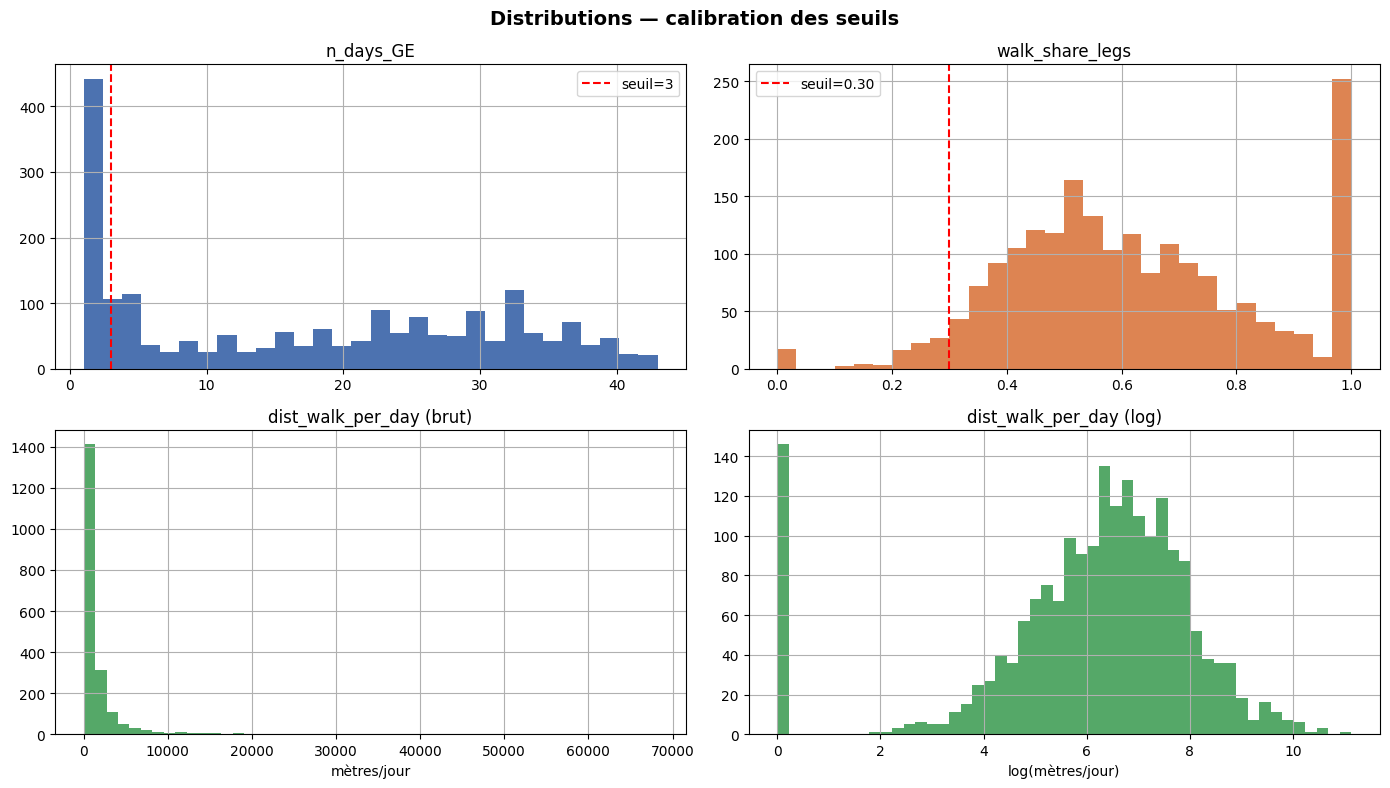

In [74]:
# ─── Dataframe permanent : une ligne par utilisateur ─────────────────────────
users_GE = legs_GG_all.drop_duplicates(subset='user_id_fors').copy()

print(f"users_GE : {len(users_GE)} utilisateurs")
print(f"Colonnes : {len(users_GE.columns)}")

# ─── Exploration des distributions ───────────────────────────────────────────
print("\n=== Distribution n_days_GE ===")
print(users_GE['n_days_GE'].describe())

print("\n=== Distribution walk_share_legs ===")
print(users_GE['walk_share_legs'].describe())

print("\n=== Distribution walk_share_dist ===")
print(users_GE['walk_share_dist'].describe())

print("\n=== Distribution dist_walk_per_day ===")
print(users_GE['dist_walk_per_day'].describe())

# ─── Sensibilité aux seuils ───────────────────────────────────────────────────
print("\n=== Sensibilité N_DAYS_MIN ===")
for n in [1, 3, 5, 7]:
    cnt = (users_GE['n_days_GE'] >= n).sum()
    print(f"  >= {n} jours : {cnt:>4} ({cnt/len(users_GE)*100:.1f}%)")

print("\n=== Sensibilité WALK_SHARE_MIN (sur n_days >= 3) ===")
_u3 = users_GE[users_GE['n_days_GE'] >= 3]
for seuil in [0.20, 0.30, 0.40, 0.50]:
    cnt = (_u3['walk_share_legs'] >= seuil).sum()
    print(f"  >= {seuil:.0%} : {cnt:>4} ({cnt/len(_u3)*100:.1f}%)")
del _u3

# ─── Visualisations ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Distributions — calibration des seuils", fontsize=14, fontweight='bold')

users_GE['n_days_GE'].hist(bins=30, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('n_days_GE')
axes[0,0].axvline(x=3, color='red', linestyle='--', label='seuil=3')
axes[0,0].legend()

users_GE['walk_share_legs'].hist(bins=30, ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('walk_share_legs')
axes[0,1].axvline(x=0.30, color='red', linestyle='--', label='seuil=0.30')
axes[0,1].legend()

users_GE['dist_walk_per_day'].hist(bins=50, ax=axes[1,0], color='#55A868')
axes[1,0].set_title('dist_walk_per_day (brut)')
axes[1,0].set_xlabel('mètres/jour')

np.log1p(users_GE['dist_walk_per_day']).hist(bins=50, ax=axes[1,1], color='#55A868')
axes[1,1].set_title('dist_walk_per_day (log)')
axes[1,1].set_xlabel('log(mètres/jour)')

plt.tight_layout()
plt.show()

### DATAFRAMES

In [75]:
N_DAYS_MIN     = 0
WALK_SHARE_MIN = 0

# ─── Colonne is_walker dans legs_GG_all ───────────────────────────────────────
legs_GG_all['is_walker'] = (
    (legs_GG_all['n_days_GE']       >= N_DAYS_MIN) &
    (legs_GG_all['walk_share_legs'] >= WALK_SHARE_MIN)
).astype(int)

# ─── Sous-dataframes legs ─────────────────────────────────────────────────────
legs_GG_walk         = legs_GG_all[legs_GG_all['mode'] == 'Mode::Walk'].copy()
legs_GG_walk_regular = legs_GG_walk[legs_GG_walk['is_walker'] == 1].copy()

# ─── Sous-dataframes users (une ligne par utilisateur) ────────────────────────
users_GG_all              = legs_GG_all.drop_duplicates(subset='user_id_fors').copy()
users_GG_walk         = legs_GG_walk.drop_duplicates(subset='user_id_fors').copy()
users_GG_walk_regular = legs_GG_walk_regular.drop_duplicates(subset='user_id_fors').copy()

# ─── Résumé ───────────────────────────────────────────────────────────────────
n_base_legs = len(legs_GG_all)
n_base_users = len(users_GG_all)

print("─── legs ──────────────────────────────────────────────────")
print(f"legs_GG_all          : {len(legs_GG_all):>6} legs (référence)")
print(f"legs_GG_walk         : {len(legs_GG_walk):>6} legs ({len(legs_GG_walk)/n_base_legs*100:.1f}%)")
print(f"legs_GG_walk_regular : {len(legs_GG_walk_regular):>6} legs ({len(legs_GG_walk_regular)/n_base_legs*100:.1f}%)")

print("\n─── users ─────────────────────────────────────────────────")
print(f"users_GG_all              : {n_base_users:>4} utilisateurs (référence)")
print(f"users_GG_walk         : {len(users_GG_walk):>4} utilisateurs ({len(users_GG_walk)/n_base_users*100:.1f}%)")
print(f"users_GG_walk_regular : {len(users_GG_walk_regular):>4} utilisateurs ({len(users_GG_walk_regular)/n_base_users*100:.1f}%)")

print(f"\nColonnes identiques dans tous les dataframes : "
      f"{len(set(legs_GG_all.columns) - set(legs_GG_walk.columns)) == 0}")

─── legs ──────────────────────────────────────────────────
legs_GG_all          : 240157 legs (référence)
legs_GG_walk         : 128613 legs (53.6%)
legs_GG_walk_regular : 128613 legs (53.6%)

─── users ─────────────────────────────────────────────────
users_GG_all              : 1997 utilisateurs (référence)
users_GG_walk         : 1980 utilisateurs (99.1%)
users_GG_walk_regular : 1980 utilisateurs (99.1%)

Colonnes identiques dans tous les dataframes : True


In [76]:
print("── Distribution Q120 (revenu ménage CHF) ────────────")
print(users_GG_walk_regular["Q120_label"].value_counts().reindex(income_order_Q120))
print()
print("── Distribution Q121 (revenu ménage €) ───────────")
print(users_GG_walk_regular["Q121_label"].value_counts().reindex(income_order_Q121))

── Distribution Q120 (revenu ménage CHF) ────────────
Q120_label
< 2'000 CHF                           11
2'000 – 4'000 CHF                     80
4'001 – 6'000 CHF                    175
6'001 – 8'000 CHF                    187
8'001 – 10'000 CHF                   193
10'001 – 12'000 CHF                  155
12'001 – 14'000 CHF                   98
14'001 – 16'000 CHF                   94
> 16'000 CHF                         185
Don't know / Prefer not to answer     78
Name: count, dtype: int64

── Distribution Q121 (revenu ménage €) ───────────
Q121_label
< 1'000 €                                  3
1'001 - 2'000 €                           27
2'001 - 3'000 €                           38
3'001 - 4'000 €                           63
4'001 - 5'000 €                           76
5'001 - 6'000 €                           68
6'001 - 7'000 €                           61
7'001 - 8'000 €                           56
8'001 - 9'000 €                           52
9'001 - 10'000 €               

In [77]:
print("── Distribution Q120 (revenu ménage CHF) ────────────")
print(users_GG_walk_regular["Q120_label"].value_counts().reindex(income_order_Q120))
n_q120 = users_GG_walk_regular["Q120_label"].notna().sum()
n_q120_nan = users_GG_walk_regular["Q120_label"].isna().sum()
print(f"\nTotal répondants Q120 : {n_q120} / NaN : {n_q120_nan}")

print()
print("── Distribution Q121 (revenu personnel €) ───────────")
print(users_GG_walk_regular["Q121_label"].value_counts().reindex(income_order_Q121))
n_q121 = users_GG_walk_regular["Q121_label"].notna().sum()
n_q121_nan = users_GG_walk_regular["Q121_label"].isna().sum()
print(f"\nTotal répondants Q121 : {n_q121} / NaN : {n_q121_nan}")

print()
print("── Résumé ───────────────────────────────────────────")
print(f"Q120 uniquement (CHF)  : {users_GG_walk_regular['Q120'].notna().sum()}")
print(f"Q121 uniquement (€)    : {users_GG_walk_regular['Q121'].notna().sum()}")
print(f"Les deux renseignés    : {(users_GG_walk_regular['Q120'].notna() & users_GG_walk_regular['Q121'].notna()).sum()}")
print(f"Aucun renseigné        : {(users_GG_walk_regular['Q120'].isna() & users_GG_walk_regular['Q121'].isna()).sum()}")

── Distribution Q120 (revenu ménage CHF) ────────────
Q120_label
< 2'000 CHF                           11
2'000 – 4'000 CHF                     80
4'001 – 6'000 CHF                    175
6'001 – 8'000 CHF                    187
8'001 – 10'000 CHF                   193
10'001 – 12'000 CHF                  155
12'001 – 14'000 CHF                   98
14'001 – 16'000 CHF                   94
> 16'000 CHF                         185
Don't know / Prefer not to answer     78
Name: count, dtype: int64

Total répondants Q120 : 1256 / NaN : 724

── Distribution Q121 (revenu personnel €) ───────────
Q121_label
< 1'000 €                                  3
1'001 - 2'000 €                           27
2'001 - 3'000 €                           38
3'001 - 4'000 €                           63
4'001 - 5'000 €                           76
5'001 - 6'000 €                           68
6'001 - 7'000 €                           61
7'001 - 8'000 €                           56
8'001 - 9'000 €                

In [78]:
# ─── Diagnostic des NaN ───────────────────────────────────────────────────
print(f"users_GG_walk_regular               : {len(users_GG_walk_regular)}")
print(f"respondants_wave1 total       : {len(respondants_wave1)}")
print()

# Combien de user_stat ont un match dans respondants_wave1 ?
matched = users_GG_walk_regular["user_id_fors"].isin(respondants_wave1["id"])
print(f"Users avec match wave1        : {matched.sum()}")
print(f"Users SANS match wave1        : {(~matched).sum()}  ← pas dans wave1 du tout")
print()

# Parmi ceux qui ont un match, combien ont des NaN dans Q10 ?
user_stat_matched = users_GG_walk_regular[matched]
nan_q10 = user_stat_matched["Q10_1_R"].isna().sum()
print(f"Users avec match mais Q10 NaN : {nan_q10}  ← ont répondu au wave1 mais pas à Q10")

users_GG_walk_regular               : 1980
respondants_wave1 total       : 10456

Users avec match wave1        : 1884
Users SANS match wave1        : 96  ← pas dans wave1 du tout

Users avec match mais Q10 NaN : 32  ← ont répondu au wave1 mais pas à Q10


In [79]:
# ─── Check legs with NaN trip_id ──────────────────────────────────────────────
nan_trip = legs_GG_walk_regular[legs_GG_walk_regular["trip_id"].isna()]

print(f"Legs with NaN trip_id : {len(nan_trip)}")
print("\n── Sample of leg_id with NaN trip_id ───────────────")
print(nan_trip["leg_id"].head(20).to_string())

# ─── Check if those leg_id exist in the trip_journey CSV ──────────────────────
missing_in_csv = nan_trip["leg_id"][~nan_trip["leg_id"].isin(leg_trip_journey["leg_id"])]
present_in_csv = nan_trip["leg_id"][ nan_trip["leg_id"].isin(leg_trip_journey["leg_id"])]

print(f"\nNaN leg_id NOT found in trip_journey CSV : {len(missing_in_csv)}")
print(f"NaN leg_id found in trip_journey CSV     : {len(present_in_csv)}")

Legs with NaN trip_id : 2217

── Sample of leg_id with NaN trip_id ───────────────
5      064e2e23-5186-4d49-b560-abd18cfc19c3
121    bde5beda-b361-483b-a43b-7228d036fd67
146    0a940097-3700-4ba1-8fa8-2b53575a3c0e
147    23af66c2-b033-4e57-b5b3-1de4cb6cf046
160    4566dd46-f039-4bc2-9b76-c9911ff12493
161    e94b0962-2282-45c2-ac9b-275058182048
168    e2db241b-b491-46f0-af1f-eca44a0e4d66
171    684a4549-efe8-4d47-a8a6-37661d83b719
172    0685cd80-cc7c-4b62-bd30-3235a1d1f615
173    dd77119f-af28-4cea-98f9-ccf0ae647d3c
174    aba985f0-20d3-4b16-ac09-87bac8f658e8
175    fcc5715d-6acc-4629-b5aa-c01d383b1408
176    33df543a-ed48-4eb4-874b-c4cd2c4084ae
184    0c4e3c1f-f761-4b0b-85af-ee2147772e6f
185    e2b79a40-149d-422d-a8a4-c9b4756618b2
186    2e88d597-0393-43e2-b786-1eb4c5471f6e
187    66f9acd1-6469-4f22-a183-6ba633c39e34
194    54039a54-fcd0-470d-912c-87e199520dca
334    b63cdbed-b077-424b-a7cd-c3231c6995de
346    86fc8537-1ddf-4dbb-8d96-488bbe459ab6

NaN leg_id NOT found in trip_journey

In [80]:
# ─── Profile of legs with NaN trip_id ─────────────────────────────────────────
nan_trip = legs_GG_walk_regular[legs_GG_walk_regular["trip_id"].isna()]

print("── Distance ──────────────────────────────────────────")
print(f"Median length : {nan_trip['length_leg'].median():.0f} m")
print(f"Mean length   : {nan_trip['length_leg'].mean():.0f} m")

print("\n── Purpose ───────────────────────────────────────────")
print(nan_trip["leading_stay_purpose"].value_counts())

print("\n── Source layer ──────────────────────────────────────")
print(nan_trip["source_layer"].value_counts())

── Distance ──────────────────────────────────────────
Median length : 156 m
Mean length   : 331 m

── Purpose ───────────────────────────────────────────
leading_stay_purpose
work              530
home              509
shopping          128
unknown           108
wait               96
leisure            91
errand             67
sport              62
eat                58
family_friends     48
medical_visit      16
study              14
other              12
assistance         11
Name: count, dtype: int64

── Source layer ──────────────────────────────────────
source_layer
layer_GE              958
layer_Fra             809
layer_VD              377
layer_not_declared     72
layer_BE                1
Name: count, dtype: int64


In [81]:
legs_GG_walk_regular.head()

,leg_id,user_id_day,user_id_motiontag,user_id_fors,type,legs_date,started_at,started_at_timezone,finished_at,finished_at_timezone,...,total_duration_walk_min,mean_walk_duration_per_day,speed_kmh,timestamp_error,income_class_GE,income_class_FR,income_class,has_car,walk_intensity,is_walker
1,3995dcbe-47a8-4ac0-9e23-0761f6d56c3b,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 15:37:52,Europe/Zurich,2023-04-25 15:48:03,Europe/Zurich,...,422.065672,14.068856,1.042881,0,High income,NaN,High income,Car owner,Modéré (500m-1km),1
3,d831bc52-3650-4c51-9b49-59ab1b2f386d,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 15:57:59,Europe/Zurich,2023-04-25 15:59:27,Europe/Zurich,...,422.065672,14.068856,3.722727,0,High income,NaN,High income,Car owner,Modéré (500m-1km),1
5,064e2e23-5186-4d49-b560-abd18cfc19c3,CH10003_20230426,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-26,2023-04-26 05:13:42,Europe/Zurich,2023-04-26 05:20:35,Europe/Zurich,...,422.065672,14.068856,1.115738,0,High income,NaN,High income,Car owner,Modéré (500m-1km),1
7,cfb7d6aa-12ae-46d6-88c8-513a902aad17,CH10003_20230426,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-26,2023-04-26 05:45:26,Europe/Zurich,2023-04-26 05:47:45,Europe/Zurich,...,422.065672,14.068856,5.490647,0,High income,NaN,High income,Car owner,Modéré (500m-1km),1
8,1ced3f6b-b4d5-4968-a7d5-fc0d570dac08,CH10003_20230426,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-26,2023-04-26 10:03:46,Europe/Zurich,2023-04-26 10:09:51,Europe/Zurich,...,422.065672,14.068856,3.106849,0,High income,NaN,High income,Car owner,Modéré (500m-1km),1


In [82]:
from IPython.display import display, HTML
display(HTML(legs_GG_walk_regular.drop(columns='geometry').head(10).to_html()))

,leg_id,user_id_day,user_id_motiontag,user_id_fors,type,legs_date,started_at,started_at_timezone,finished_at,finished_at_timezone,length_leg,duration,leading_stay_purpose,detected_mode,mode,started_on,misdetected_completely,merged,confirmed_at,created_at,updated_at,started_at_in_timezone,finished_at_in_timezone,confirmed_at_in_timezone,created_at_in_timezone,updated_at_in_timezone,point_per_linestring,max_signlalloss_meters,rel_max_signalloss,low_quality_legs_1,low_quality_legs_2,leading_stay_id,usr_w_constant_bad_signal,leading_activity_in_KT,leading_activity_in_panel,main_journey_act_KT,KT_home_survey,intra_GE,intra_VD,intra_panel,extreme95_length_detected_mode,extreme98_length_detected_mode,extreme99_length_detected_mode,extreme95_length_mode,extreme98_length_mode,extreme99_length_mode,intra_GG,source_layer,Unnamed: 0_x,first_activity_date,last_activity_date,days_in_range,gps_days_count,days_without_gps,track_days_count,staypoint_days_count,count_days_w_journey_in_GE,count_days_w_journey_in_VD,gps_activity_rate,confirmed_tracks_count,tracks_count,confirmation_tracks_score,confirmed_stay_count,stay_count,confirmation_stay_score,ID_municipality_survey,home_geometry_from_survey,ID_Agglo_survey,N_Agglo_survey,typo_panel_home_survey,KT_home_gps,home_geometry_from_gps,gdr,prof,age_fr,wgt_cant_gps,wgt_agg_gps,wgt_cant_trim_gps,wgt_agg_trim_gps,main_motor,car_in_HH_count,Q10_1_R,Q10_2_R,Q10_3_R,Q10_4_R,Q10_5_R,Q10_6_R,Q10_7_R,Q10_8_R,Q10_9_R,main_tp_abo,tp_level,Q11_1_R,Q11_2_R,Q11_3_R,Q11_4_R,Q11_5_R,Q11_6_R,Q11_7_R,Q11_8_R,Q11_9_R,main_mobility_abo,mobility_level,Q120,Q120_label,Q121,Q121_label,Q108_new,physical_cond_label,Q119_1,Q119_2,Q119_3,Q119_4,Q119_5,Q119_6,Q119_7,Q119_8,Q119_9,Unnamed: 0_y,trip_id,journey_id,age_fr_grouped,length_weighted,mode_group,a_repondu_revenu,n_legs_total,dist_total,n_days_GE,dist_2WV,dist_airplane,dist_bicycle,dist_boat,dist_car,dist_other,dist_public_transit,dist_train,dist_vehicle_equivalent_device,dist_walk,n_legs_2WV,n_legs_airplane,n_legs_bicycle,n_legs_boat,n_legs_car,n_legs_other,n_legs_public_transit,n_legs_train,n_legs_vehicle_equivalent_device,n_legs_walk,n_walk_days,dist_walk_per_day,share_dist_walk,share_legs_walk,dist_car_per_day,share_dist_car,share_legs_car,dist_public_transit_per_day,share_dist_public_transit,share_legs_public_transit,dist_train_per_day,share_dist_train,share_legs_train,dist_bicycle_per_day,share_dist_bicycle,share_legs_bicycle,dist_vehicle_equivalent_device_per_day,share_dist_vehicle_equivalent_device,share_legs_vehicle_equivalent_device,dist_2WV_per_day,share_dist_2WV,share_legs_2WV,dist_boat_per_day,share_dist_boat,share_legs_boat,dist_airplane_per_day,share_dist_airplane,share_legs_airplane,dist_other_per_day,share_dist_other,share_legs_other,walk_share_dist,walk_share_legs,dist_walk_per_walk_day,mean_walk_legs_per_day,started_at_local,finished_at_local,hour,hour_end,time_slot,day_of_week,day_of_week_num,duration_min,duration_min_weighted,total_duration_walk_min,mean_walk_duration_per_day,speed_kmh,timestamp_error,income_class_GE,income_class_FR,income_class,has_car,walk_intensity,is_walker
1,3995dcbe-47a8-4ac0-9e23-0761f6d56c3b,CH10003_20230425,18123160-132f-4293-a11f-45c93ed1855a,CH10003,Track,2023-04-25,2023-04-25 15:37:52,Europe/Zurich,2023-04-25 15:48:03,Europe/Zurich,177.0,611.0,wait,Mode::Walk,Mode::Walk,2023-04-25,f,f,2023-04-26 16:33:41.941,2023-04-25 16:13:16.888,2023-04-26 16:33:41.941,2023-04-25T17:37:52+02:00,2023-04-25T17:48:03+02:00,2023-04-26T16:33:41Z,2023-04-25T16:13:16Z,2023-04-26T16:33:41Z,29,88.624728,0.498877,0,0,c198bb5c-0345-4cab-83f5-486a82fc5257,0,VD,1.0,VD,VD,0.0,1.0,1.0,False,False,False,False,False,False,1,layer_VD,274,2023-04-24,2023-05-31,38,37,1,36,37,2,33,0.973684,236,236,100,188,188,100,5586.0,POINT (6.2254403 46.39407629999999),6621,Genève,B,VD,POINT (6.230720433636626 46.391947120815175),Homme,Population active occupée,45-59 ans,0.450115,0.27144,0.450115,0.27144,essence,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Demi-tarif,1,1.0

In [83]:
print(legs_GG_walk_regular.dtypes.to_string())

leg_id                                                           object
user_id_day                                                      object
user_id_motiontag                                                object
user_id_fors                                                     object
type                                                             object
legs_date                                                        object
started_at                                               datetime64[ms]
started_at_timezone                                              object
finished_at                                              datetime64[ms]
finished_at_timezone                                             object
length_leg                                                      float64
duration                                                        float64
leading_stay_purpose                                             object
detected_mode                                                   

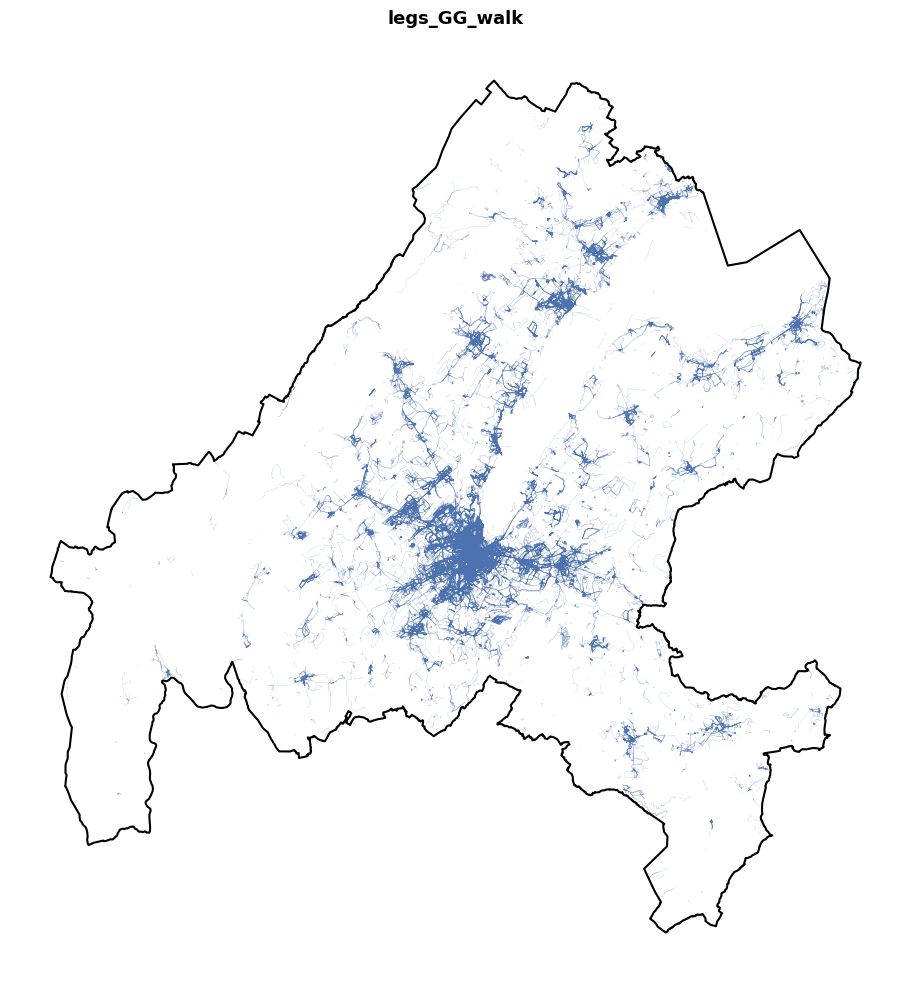

In [84]:
# ─── Reprojection pour le plot ────────────────────────────────────────────────
legs_plot   = legs_GG_walk_regular.to_crs(epsg=2056)
canton_plot = agglo_GG 

fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle("legs_GG_walk", fontsize=13, fontweight="bold") #legs_GG_walk_regular = same as legs_GG_walk because parametre for regular walker = set to 0

legs_plot.plot(ax=ax, color="#4C72B0", linewidth=0.3, alpha=0.3)
canton_plot.boundary.plot(ax=ax, color='black', linewidth=1.5)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [85]:
print(f"CRS legs_GG_walk_regular : {legs_GG_walk_regular.crs}")
print(f"CRS agglo_GG            : {agglo_GG.crs}")
print(f"\nBounds legs_GG_walk_regular : {legs_GG_walk_regular.total_bounds}")
print(f"Bounds agglo_GG            : {agglo_GG.total_bounds}")

# ─── Chercher les géométries hors canton ─────────────────────────────────────
xmin_c, ymin_c, xmax_c, ymax_c = agglo_GG.total_bounds

# Bounding box de chaque leg
bounds = legs_GG_walk_regular.bounds
hors_canton = legs_GG_walk_regular[
    (bounds["minx"] < xmin_c) | 
    (bounds["maxx"] > xmax_c) | 
    (bounds["miny"] < ymin_c) | 
    (bounds["maxy"] > ymax_c)
]

print(f"\nLegs hors bounding box canton : {len(hors_canton)}")
if len(hors_canton) > 0:
    print(f"Bounds des legs hors canton : {hors_canton.total_bounds}")

CRS legs_GG_walk_regular : EPSG:4326
CRS agglo_GG            : EPSG:2056

Bounds legs_GG_walk_regular : [ 5.71055211 45.94719348  6.54357131 46.54128377]
Bounds agglo_GG            : [2465789.4328 1086777.4394 2531325.5829 1155694.86  ]

Legs hors bounding box canton : 128613
Bounds des legs hors canton : [ 5.71055211 45.94719348  6.54357131 46.54128377]


# EXPORTS

In [86]:
# ─── Export des legs ──────────────────────────────────
legs_exports = {
    'legs_GG_all'          : legs_GG_all,
    'legs_GG_walk'         : legs_GG_walk,
    'legs_GG_walk_regular' : legs_GG_walk_regular,
}

for name, gdf in legs_exports.items():
    base = os.path.join(output_file_path_PL, name)
    gdf_projected = gdf.to_crs(target_crs)
    gdf_projected.to_file(f"{base}.gpkg",     driver="GPKG")
    gdf_projected.to_parquet(f"{base}.parquet")
    gdf_projected.to_csv(f"{base}.csv",        index=False)
    print(f"{name} exporté → .gpkg / .parquet / .csv ({len(gdf):,} legs)")

legs_GG_all exporté → .gpkg / .parquet / .csv (240,157 legs)
legs_GG_walk exporté → .gpkg / .parquet / .csv (128,613 legs)
legs_GG_walk_regular exporté → .gpkg / .parquet / .csv (128,613 legs)


In [87]:
# ─── Export des users ─────────────────────
users_exports = {
    'users_GE'              : users_GE,
    'users_GG_walk'         : users_GG_walk,
    'users_GG_walk_regular' : users_GG_walk_regular,
}

for name, df in users_exports.items():
    # Drop géométrie si présente (les users_GE sont issus de drop_duplicates sur legs)
    df_csv = df.drop(columns='geometry', errors='ignore')
    df_csv.to_csv(os.path.join(output_file_path_PL, f"{name}.csv"), index=False)
    print(f"{name} exporté → .csv ({len(df):,} utilisateurs)")

users_GE exporté → .csv (1,997 utilisateurs)
users_GG_walk exporté → .csv (1,980 utilisateurs)
users_GG_walk_regular exporté → .csv (1,980 utilisateurs)
